# Kalman Filter Intro

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

## Stationary Object

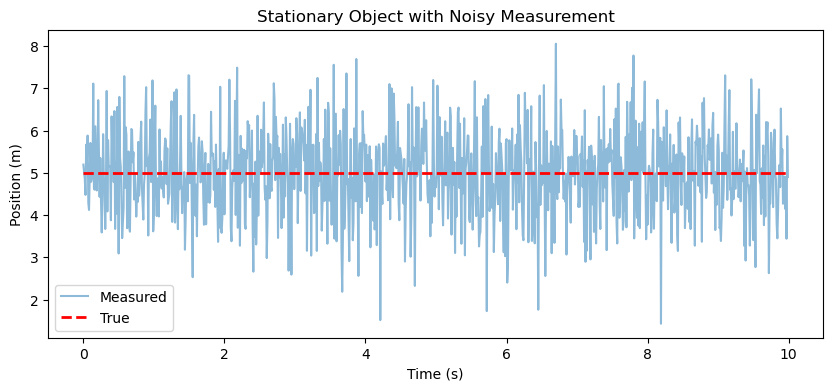

In [128]:
# Generating Stationary Object and Noisy Position Measurements

delta_t = .01
end_time = 10.0
t = np.arange(0, end_time, delta_t)

x_actual = 5.0

# instrument noise 
x_measured = x_actual + np.random.normal(0, 1.0, size = len(t))

x_actual_array = np.full(len(t), x_actual)

plt.figure(figsize = (10, 4))
plt.plot(t, x_measured, '-', alpha = 0.5, label = 'Measured')
plt.plot(t, x_actual_array, 'r--', linewidth = 2, label = 'True')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Stationary Object with Noisy Measurement')
plt.legend()
plt.show()

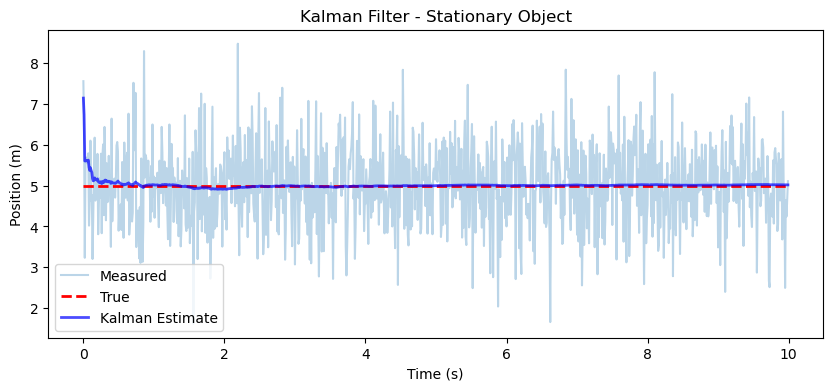

In [126]:
# Kalman Filter for Stationary Object

x_estd = 3.0
P = 10.0  # initial uncertainty
Q = 0.0   # our constant-position model describes the object's behavior perfectly
R = 1.0   # variance of instrument noise (our random noise has std 1.0)

estimates = []
for val in x_measured:
    x_pred = x_estd
    P_pred = P + Q
    K = P_pred / (P_pred + R)
    P = (1 - K) * P_pred
    # generate new x estimate
    x_estd = x_pred + K * (val - x_pred)
    estimates.append(x_estd)
   
plt.figure(figsize = (10, 4))
plt.plot(t, x_measured, alpha = 0.3, label = 'Measured')
plt.plot(t, x_actual_array, 'r--', linewidth = 2, label = 'True')
plt.plot(t, estimates, 'b-', linewidth = 2, alpha = .7, label = 'Kalman Estimate')
plt.title('Kalman Filter - Stationary Object')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.show()

## Moving Object

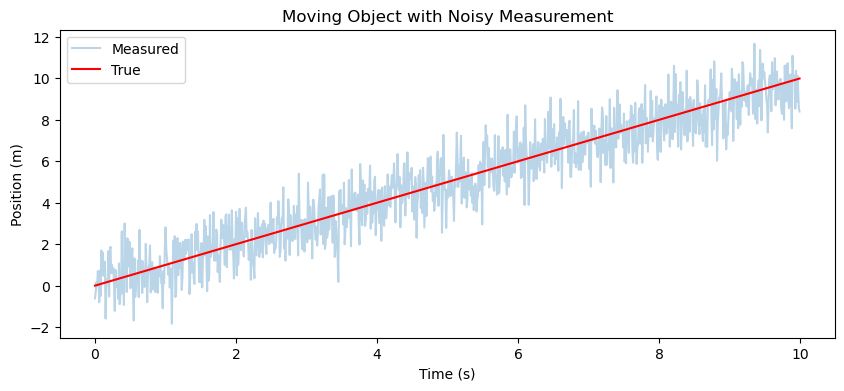

In [163]:
# Generating Position Data for Constant-Velocity Object

x_0_true = 0.0
v_true = 1.0
v_true_array = np.full(len(t), v_true)
x_true_moving = x_0_true + v_true*t
x_measured_moving = x_true_moving + np.random.normal(0, 1.0, size=len(t))

plt.figure(figsize=(10,4))
plt.plot(t, x_measured_moving, alpha = 0.3, label = 'Measured')
plt.plot(t, x_true_moving, 'r-', label = 'True')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Moving Object with Noisy Measurement')
plt.legend()
plt.show()

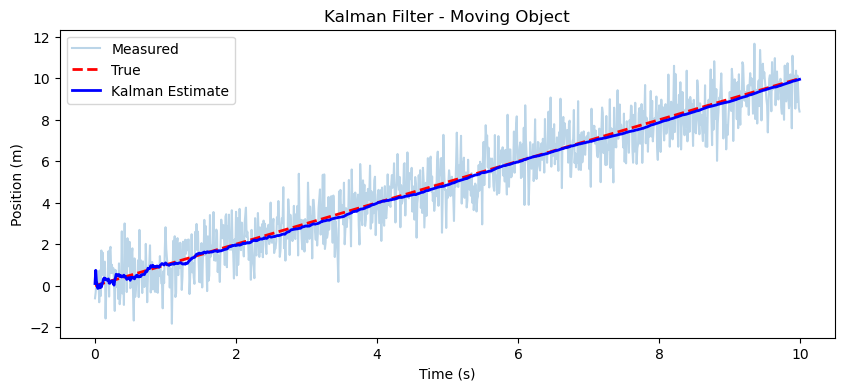

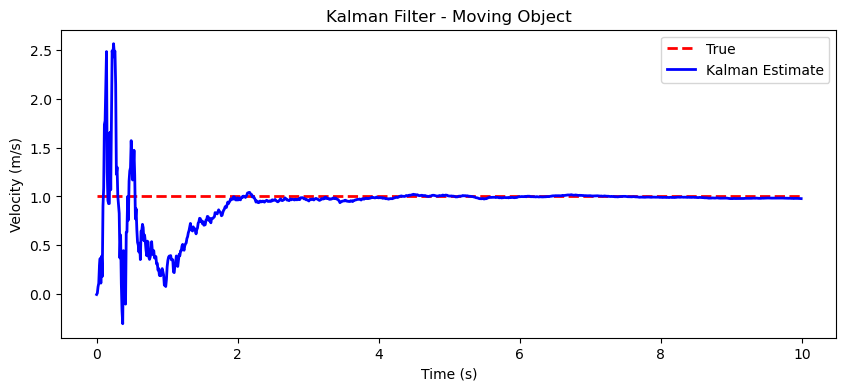

In [164]:
# Kalman Filter for Moving Object

x_0_est = 0.0
v_est = 0.0
X_est_cv = np.array([[x_0_est], [v_est]])
F = np.array([[1, delta_t], [0, 1]])   # F@X(t) = X(t+1)
H = np.array([[1, 0]])                 # extracts position scalar from our X vector during H@X matrix mult.

P = np.array([[10.0, 0.0], [0.0, 10.0]])  # initial uncertainty matrix: P(1,1) = x_0 uncertainty and P(2,2) = v uncertainty
Q = np.array([[0.0, 0.0], [0.0, 0.0]])    # our constant-velocity model describes object perfectly
R = np.array([[1.0]])                     # variance of instrument noise (our random noise has std 1.0),
                                          # R is a scalar here because we only have one sensor

estimates_x_cv = []
estimates_v_cv = []
for val in x_measured_moving:
    X_pred = F @ X_est_cv
    P_pred = F @ P @ F.T + Q    # when performing linear transformation F, multiply F by covariance matrix by F transpose
    S = (H@P_pred@H.T + R)                        # this is "innovation covariance matrix," shows uncertainty of innovation vector,
    K = (P_pred @ H.T) @ np.linalg.inv(S)         # which is the difference between measurement and prediction
    P = (np.eye(2) - K @ H) @ P_pred
    # generate new x estimate:
    X_est_cv = X_pred + K @ (np.array([[val]]) - H @ X_pred)
    estimates_x_cv.append(float(X_est_cv[0, 0]))
    estimates_v_cv.append(float(X_est_cv[1, 0]))

# position plot
plt.figure(figsize = (10, 4))
plt.plot(t, x_measured_moving, alpha = 0.3, label = 'Measured')
plt.plot(t, x_true_moving, 'r--', linewidth = 2, label = 'True')
plt.plot(t, estimates_cv, 'b-', linewidth = 2, label = 'Kalman Estimate')
plt.title('Kalman Filter - Moving Object')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.show()

# velocity plot
plt.figure(figsize = (10, 4))
plt.plot(t, v_true_array, 'r--', linewidth = 2, label = 'True')
plt.plot(t, estimates_v_cv, 'b-', linewidth = 2, label = 'Kalman Estimate')
plt.title('Kalman Filter - Moving Object')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.show()
